# Predicción del Consumo Eléctrico Diario — MSI608 Proyecto 1

**Notebook autónomo**: no depende de archivos `.py` externos ni de un CSV en
disco. El dataset `data_ys.csv` viene **embebido** en base64 dentro del propio
notebook, y todas las funciones están definidas aquí. Basta con este único
archivo `.ipynb`.

Se predice el consumo **diario** a un paso y las predicciones se **agregan** a
nivel semanal, mensual y anual. Metodología basada en los talleres del curso:
series de tiempo (ACF/PACF, ADF), modelo clásico **SARIMA** y red neuronal
**MLP** con ventana deslizante, cuya arquitectura se elige con **keras-tuner**.

> Todas las celdas de código están comentadas explicando qué hace cada paso.

## 1. Importación de librerías

In [1]:
# --- Librerías estándar ---
import base64, io                 # para decodificar el dataset embebido (base64)
import random as rd               # semillas de aleatoriedad

# --- Cálculo y gráficos ---
import numpy as np                # arreglos numéricos y operaciones vectorizadas
import pandas as pd               # series/tablas con índice de fechas
import matplotlib.pyplot as plt   # gráficos
%matplotlib inline

# --- Series de tiempo (statsmodels), usadas en los talleres 2 y 3 ---
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf   # autocorrelaciones
from statsmodels.tsa.stattools import adfuller                   # test de estacionariedad
from statsmodels.tsa.seasonal import seasonal_decompose          # descomposición estacional
from statsmodels.tsa.statespace.sarimax import SARIMAX           # modelo SARIMA

# --- Red neuronal (Keras/TensorFlow) y búsqueda de hiperparámetros ---
import tensorflow as tf
import keras_tuner
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.optimizers import Adam

## 2. Dataset embebido (`data_ys.csv` en base64)

El contenido del CSV está codificado en base64 en la variable `_CSV_B64`. Se
decodifica en memoria (sin leer archivos), evitando depender de un CSV externo.

In [2]:
# Contenido de data_ys.csv codificado en base64 (year, month, day, consumption)
_CSV_B64 = """
...
LDEyLDMxLDEyMi41NzkwNDYyNDk5OTk5OQo=
"""

# Decodificamos: quitamos saltos de línea, pasamos de base64 a texto y lo leemos con pandas
_csv_texto = base64.b64decode("".join(_CSV_B64.split())).decode("utf-8")
df = pd.read_csv(io.StringIO(_csv_texto))
print("Filas leídas:", len(df))
df.head()

Filas leídas: 1461


,year,month,day,consumption
0,2018,1,1,103.311114
1,2018,1,2,138.795583
2,2018,1,3,123.858912
3,2018,1,4,133.034709
4,2018,1,5,162.777800


## 3. Preparación de la serie

Se construye un índice de fechas a partir de year/month/day, se ordena y se
fuerza frecuencia diaria (`asfreq('D')`), igual que en el taller 3.

In [3]:
# Creamos una columna 'fecha' de tipo datetime a partir de year/month/day
df["fecha"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=df["day"]))

# Usamos la fecha como índice, ordenamos cronológicamente y tomamos la columna de consumo.
# asfreq('D') fija frecuencia diaria (revela huecos si los hubiera).
serie = df.set_index("fecha").sort_index()["consumption"].asfreq("D")
serie.name = "consumo"

print(serie.index.min(), "->", serie.index.max(), "| n =", len(serie))
serie.head()

2018-01-01 00:00:00 -> 2021-12-31 00:00:00 | n = 1461


fecha
2018-01-01    103.311114
2018-01-02    138.795583
2018-01-03    123.858912
2018-01-04    133.034709
2018-01-05    162.777800
Freq: D, Name: consumo, dtype: float64

## 4. Funciones auxiliares (definidas dentro del notebook)

En lugar de importarlas desde `.py`, se definen aquí para que el notebook sea
autónomo: métricas, ventanas deslizantes, partición y los tres modelos.

In [4]:
# ---------- MÉTRICAS ----------
# Se reportan MSE (loss de la MLP), RMSE y MAE (unidades de consumo), MAPE (% relativo)
# y R2 (bondad de ajuste: 1 = perfecto, 0 = como predecir la media, <0 = peor).
def mse(yt, yp):  yt, yp = np.asarray(yt, float), np.asarray(yp, float); return float(np.mean((yt-yp)**2))
def rmse(yt, yp): return float(np.sqrt(mse(yt, yp)))
def mae(yt, yp):  yt, yp = np.asarray(yt, float), np.asarray(yp, float); return float(np.mean(np.abs(yt-yp)))
def mape(yt, yp):
    yt, yp = np.asarray(yt, float), np.asarray(yp, float)
    m = yt != 0                                   # evitamos dividir por cero
    return float(np.mean(np.abs((yt[m]-yp[m])/yt[m]))*100)
def r2(yt, yp):                                   # coeficiente de determinación R^2
    yt, yp = np.asarray(yt, float), np.asarray(yp, float)
    ss_res = np.sum((yt - yp) ** 2)               # suma de cuadrados de los residuos
    ss_tot = np.sum((yt - np.mean(yt)) ** 2)      # suma de cuadrados total (varianza)
    return float("nan") if ss_tot == 0 else float(1 - ss_res / ss_tot)  # 1 pto => indefinido
def metricas(yt, yp):                             # devuelve todas las métricas juntas
    return {"MSE": mse(yt, yp), "RMSE": rmse(yt, yp), "MAE": mae(yt, yp),
            "MAPE": mape(yt, yp), "R2": r2(yt, yp)}

# ---------- VENTANAS DESLIZANTES ----------
# Convierte una serie 1D en pares (ventana de 'window' días -> día siguiente), como el taller 3.
def make_windows(y, window):
    X, target = [], []
    for i in range(len(y)):
        if i + window < len(y):
            X.append([y[i+j] for j in range(window)])   # 'window' días de entrada
            target.append(y[i+window])                  # día siguiente = objetivo
        else:
            break
    return np.asarray(X, "float32"), np.asarray(target, "float32")

# ---------- PARTICIÓN POR AÑO ----------
# Los años previos entrenan y el último año evalúa (no se mezcla futuro con pasado).
def split_por_anio(serie, anio_test=2021):
    train = serie[serie.index.year <  anio_test]
    test  = serie[serie.index.year == anio_test]
    return train, test

print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


In [5]:
# ---------- MODELO 1: baseline naive estacional ----------
# Predice cada día con el valor observado 'periodo' (7) días antes. Mínimo a superar.
def naive_estacional(y_train, y_test, periodo=7):
    historia = np.concatenate([y_train, y_test])
    n_train = len(y_train)
    return np.asarray([historia[n_train + i - periodo] for i in range(len(y_test))], "float32")

# ---------- MODELO 2: SARIMA (statsmodels) ----------
# Ajusta SARIMA en train y predice a UN paso sobre el test usando append(refit=False):
# incorpora cada valor real del test y predice el siguiente -> comparación justa con la MLP.
def sarima_un_paso(y_train, y_test, order=(2,1,2), seasonal_order=(1,0,1,7)):
    modelo = SARIMAX(y_train, order=order, seasonal_order=seasonal_order,
                     enforce_stationarity=False, enforce_invertibility=False)
    res = modelo.fit(disp=False)
    res_ext = res.append(y_test, refit=False)
    n = len(y_train)
    return np.asarray(res_ext.predict(start=n, end=n+len(y_test)-1), "float32")

# ---------- MODELO 3: hipermodelo MLP para keras-tuner ----------
# Espacio de búsqueda (estilo taller 0): nº de capas ocultas, neuronas y learning rate.
def construir_hypermodel(window):
    def build_model(hp):
        model = Sequential()
        model.add(Input(name="window", shape=(window,)))                 # entrada = ventana
        for _ in range(hp.Choice("capas", [1, 2, 3])):                   # nº de capas ocultas
            model.add(Dense(hp.Choice("neuronas", [32, 64, 128, 256]),   # neuronas por capa
                            activation="relu"))
        model.add(Dense(1, activation="linear"))                         # salida = 1 valor (regresión)
        lr = hp.Choice("lr", [1e-2, 1e-3, 1e-4])                         # tasa de aprendizaje
        model.compile(optimizer=Adam(learning_rate=lr), loss="mse", metrics=["mse", "mae"])
        return model
    return build_model

print("Modelos definidos.")

Modelos definidos.


## 5. Análisis Exploratorio de Datos

### 5.1 Completitud, correctitud y outliers (rúbrica)

In [6]:
s = serie.dropna()   # trabajamos sin posibles NaN

# COMPLETITUD: fechas faltantes tras forzar frecuencia diaria
esperado = pd.date_range(serie.index.min(), serie.index.max(), freq="D")
faltantes = esperado.difference(serie.dropna().index)
print("COMPLETITUD -> n:", len(serie), "| valores NaN:", int(serie.isna().sum()),
      "| fechas faltantes:", len(faltantes))

# CORRECTITUD: valores no positivos (imposibles), fechas duplicadas y rango
print("CORRECTITUD -> no positivos:", int((s<=0).sum()),
      "| duplicadas:", int(serie.index.duplicated().sum()),
      "| min:", round(float(s.min()),2), "| max:", round(float(s.max()),2))

# OUTLIERS: regla IQR (1.5 * rango intercuartil)
q1, q3 = s.quantile(0.25), s.quantile(0.75); iqr = q3 - q1
low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
out = s[(s<low) | (s>high)]
print(f"OUTLIERS    -> IQR=[{low:.1f}, {high:.1f}] | n_outliers: {len(out)} "
      f"({100*len(out)/len(s):.2f}%)")

COMPLETITUD -> n: 1461 | valores NaN: 0 | fechas faltantes: 0
CORRECTITUD -> no positivos: 0 | duplicadas: 0 | min: 32.79 | max: 250.55
OUTLIERS    -> IQR=[52.0, 265.5] | n_outliers: 2 (0.14%)


### 5.2 Estadísticas descriptivas

In [7]:
# describe() global y por año, unidos en una sola tabla
desc = s.describe().to_frame("global")
por_anio = s.groupby(s.index.year).describe().T
pd.concat([desc, por_anio], axis=1).round(2)

,global,2018,2019,2020,2021
count,1461.00,365.00,365.00,366.00,365.00
mean,157.65,166.83,157.71,147.58,158.52
std,35.98,37.00,37.45,33.05,33.73
min,32.79,32.79,73.29,44.79,76.30
25%,132.09,139.27,130.29,126.39,133.59
50%,153.44,168.74,152.12,141.00,157.90
75%,185.46,191.65,186.69,162.46,184.25
max,250.55,250.55,235.05,233.67,231.85


### 5.3 Serie temporal

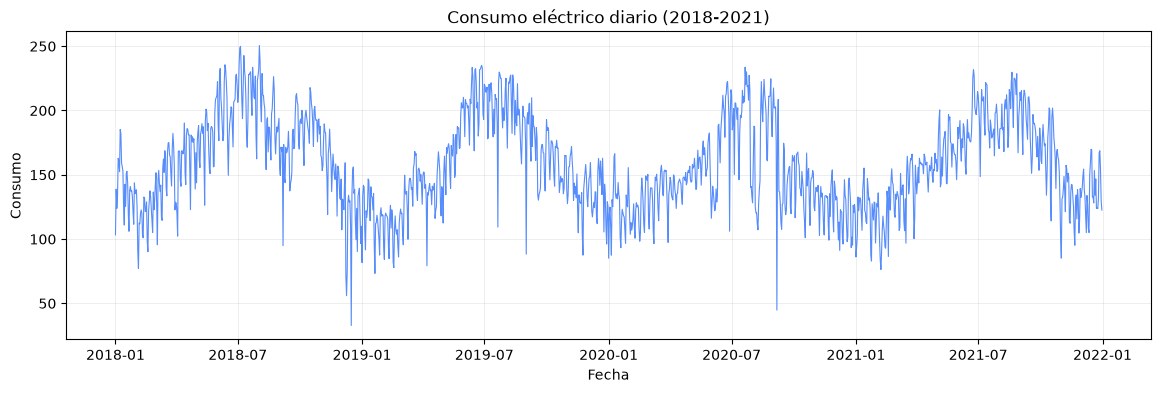

In [27]:
# Consumo diario completo: se observan estacionalidad anual y ruido semanal
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(s.index, s.values, lw=0.8)
ax.set_title("Consumo eléctrico diario (2018-2021)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Consumo"); ax.grid(True, alpha=0.3)
plt.show()

### 5.4 Autocorrelación (ACF / PACF)

Guían el orden del SARIMA (talleres 2 y 3). Se aprecia el patrón semanal (rezago 7).

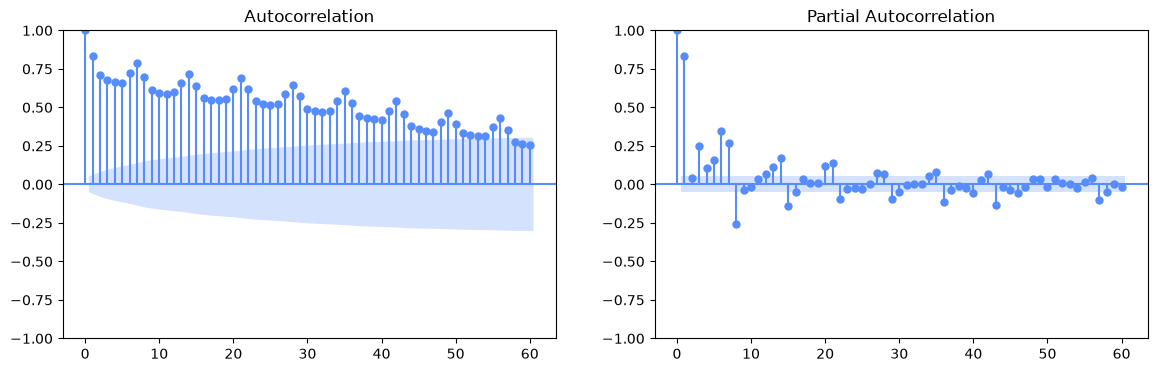

In [28]:
# ACF = memoria acumulada; PACF = memoria directa por rezago
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(s.values, lags=60, ax=axes[0])
plot_pacf(s.values, lags=60, ax=axes[1])
plt.show()

### 5.5 Estacionalidad: por mes y por día de semana

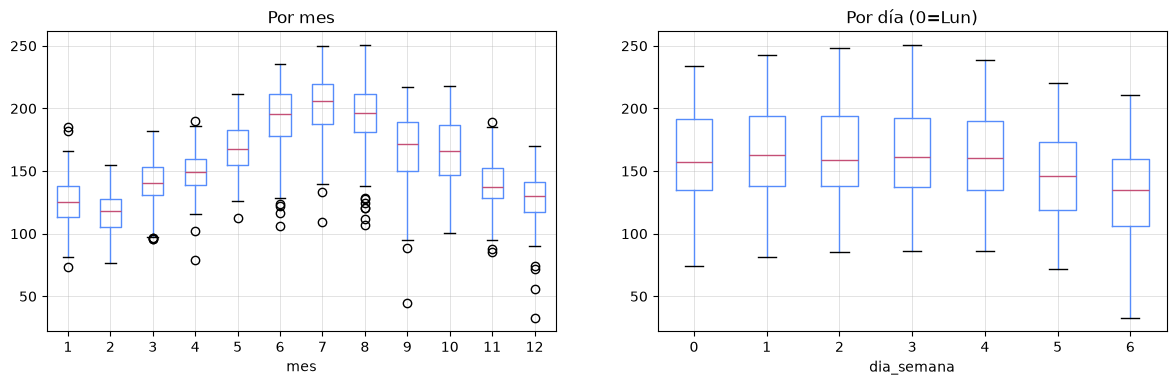

In [29]:
# Añadimos columnas de mes y día de semana para ver la estacionalidad con boxplots
d = s.to_frame("consumo")
d["mes"] = d.index.month
d["dia_semana"] = d.index.dayofweek      # 0=Lunes ... 6=Domingo
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
d.boxplot(column="consumo", by="mes", ax=axes[0]);         axes[0].set_title("Por mes")
d.boxplot(column="consumo", by="dia_semana", ax=axes[1]);  axes[1].set_title("Por día (0=Lun)")
fig.suptitle(""); plt.show()

### 5.6 Descomposición estacional (período semanal)

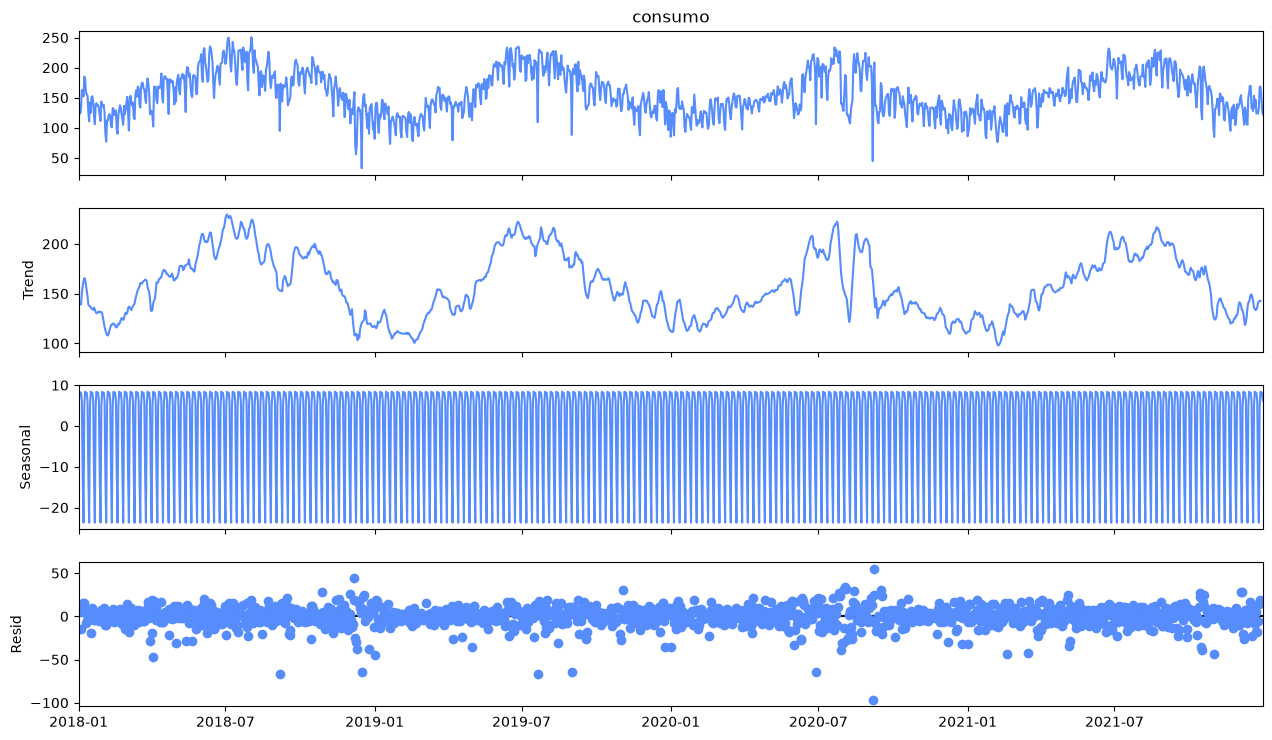

In [30]:
# Separa la serie en tendencia + estacionalidad (período 7) + residuo
result = seasonal_decompose(s, model="additive", period=7)
fig = result.plot(); fig.set_size_inches(14, 8); plt.show()

### 5.7 Estacionariedad (test ADF)

p-valor < 0.05 => estacionaria. Comparamos la serie con su primera diferencia.

In [12]:
# ADF: H0 = serie NO estacionaria. Si al diferenciar el p-valor cae <0.05, justifica d=1.
r  = adfuller(s.values)             # serie original
rd_ = adfuller(np.diff(s.values))   # primera diferencia
print(f"Original    : ADF={r[0]:.3f}  p={r[1]:.4f}")
print(f"Diferenciada: ADF={rd_[0]:.3f}  p={rd_[1]:.4f}")

Original    : ADF=-2.508  p=0.1136
Diferenciada: ADF=-11.759  p=0.0000


## 6. Definición del problema y partición

- **Entrada**: ventana de los `WINDOW` días previos.
- **Salida**: consumo del día siguiente (predicción a un paso).
- **Partición**: entrenamiento 2018–2020, prueba 2021.

In [13]:
WINDOW = 14   # nº de días previos usados como entrada

# Partición temporal (rellenamos huecos con ffill, criterio del taller 3)
train, test = split_por_anio(serie.ffill(), anio_test=2021)
y_train, y_test = train.values.astype("float32"), test.values.astype("float32")
print("train:", len(y_train), "| test:", len(y_test))

# Ventanas de entrenamiento (14 días -> día 15)
Xtr, ytr = make_windows(y_train, WINDOW)
print("Ventanas de entrenamiento:", Xtr.shape, "->", ytr.shape)

train: 1096 | test: 365
Ventanas de entrenamiento: (1082, 14) -> (1082,)


## 7. Modelos y evaluación

### 7.1 Baseline naive estacional

In [14]:
pred_naive = naive_estacional(y_train, y_test, periodo=7)   # valor de 7 días antes
print("Naive estacional:", metricas(y_test, pred_naive))

Naive estacional: {'MSE': 439.5974192657578, 'RMSE': 20.966578625654634, 'MAE': 16.403527163152827, 'MAPE': 11.09107922221068, 'R2': 0.6125082224976137}


### 7.2 SARIMA

In [15]:
# Ajuste + predicción a un paso sobre todo el test 2021
pred_sarima = sarima_un_paso(y_train, y_test, order=(2,1,2), seasonal_order=(1,0,1,7))
print("SARIMA:", metricas(y_test, pred_sarima))

SARIMA: {'MSE': 168.3673530508241, 'RMSE': 12.975644610223576, 'MAE': 9.74735918436965, 'MAPE': 6.720007109021486, 'R2': 0.8515892904557878}


D:\MAGISTER\MSI608 TOPIC ESPECIAL CIENCIA DE DATO\proyecto1-2026\.venv311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### 7.3 MLP con ventana deslizante + keras-tuner

La arquitectura (capas, neuronas, learning rate) se elige experimentalmente con
keras-tuner (taller 0).

In [16]:
# --- Semillas para reproducibilidad ---
SEED = 121208
rd.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# --- Ventanas de TEST con historia real (una predicción por cada día del test) ---
# Para cada día t del test tomamos los WINDOW días previos (incluye cola del train).
y_all = serie.ffill().values.astype("float32"); n_train = len(y_train)
Xte, yte = [], []
for t in range(n_train, len(y_all)):
    Xte.append(y_all[t-WINDOW:t]); yte.append(y_all[t])
Xte, yte = np.asarray(Xte, "float32"), np.asarray(yte, "float32")

# --- Estandarización con estadísticos del TRAIN (evita fuga de información) ---
mu, sg = float(ytr.mean()), float(ytr.std())

# --- Búsqueda de arquitectura con keras-tuner (RandomSearch) ---
build = construir_hypermodel(WINDOW)
tuner = keras_tuner.RandomSearch(
    build, objective=keras_tuner.Objective("val_mse", "min"),
    max_trials=8, executions_per_trial=1, overwrite=True,
    directory="tuner_nb", project_name="consumo", seed=SEED)
tuner.search((Xtr-mu)/sg, (ytr-mu)/sg, epochs=30, validation_split=0.15, verbose=0)

# Mejor combinación encontrada
best = tuner.get_best_hyperparameters(1)[0]
print("Mejor arquitectura:", {k: best.get(k) for k in ("capas","neuronas","lr")})

# --- Entrenamiento final del mejor modelo (con early stopping) ---
model = tuner.hypermodel.build(best)
hist = model.fit((Xtr-mu)/sg, (ytr-mu)/sg, validation_split=0.15,
                 epochs=80, batch_size=64, verbose=0,
                 callbacks=[tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)])

# --- Predicción sobre el test: escalar entrada, predecir y des-escalar salida ---
pred_mlp = model.predict((Xte-mu)/sg, verbose=0).ravel()*sg + mu
print("MLP:", metricas(yte, pred_mlp))


Mejor arquitectura: {'capas': 3, 'neuronas': 256, 'lr': 0.0001}
MLP: {'MSE': 194.66462063996477, 'RMSE': 13.952226368575188, 'MAE': 10.431780943152022, 'MAPE': 7.19910082378569, 'R2': 0.8284090475449175}


### 7.4 Curva de entrenamiento

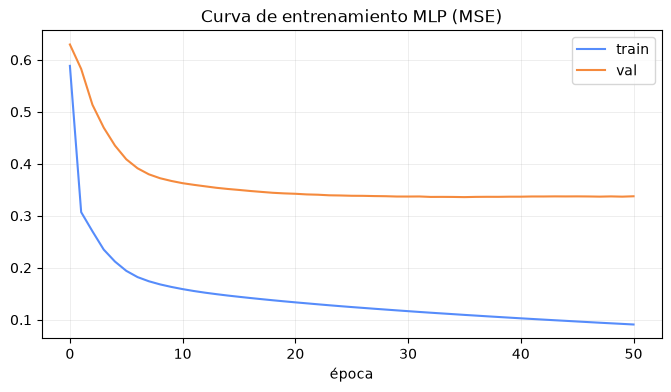

In [32]:
# Evolución del error (MSE) en train y validación por época; detecta sobreajuste
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(hist.history["loss"], label="train")
ax.plot(hist.history["val_loss"], label="val")
ax.set_title("Curva de entrenamiento MLP (MSE)")
ax.set_xlabel("época"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 8. Resultados

### 8.1 Métricas diarias (test 2021)

In [18]:
# Alineamos los tres modelos a la misma longitud (la de la MLP) para comparar igual
preds = {"naive_estacional": pred_naive[-len(yte):],
         "SARIMA": pred_sarima[-len(yte):],
         "MLP": pred_mlp}
tabla = pd.DataFrame({k: metricas(yte, v) for k, v in preds.items()}).T
tabla.round(3)   # menor RMSE/MAE/MAPE = mejor

,MSE,RMSE,MAE,MAPE,R2
naive_estacional,439.597,20.967,16.404,11.091,0.613
SARIMA,168.367,12.976,9.747,6.720,0.852
MLP,194.665,13.952,10.432,7.199,0.828


### 8.2 Comparación visual real vs predicho

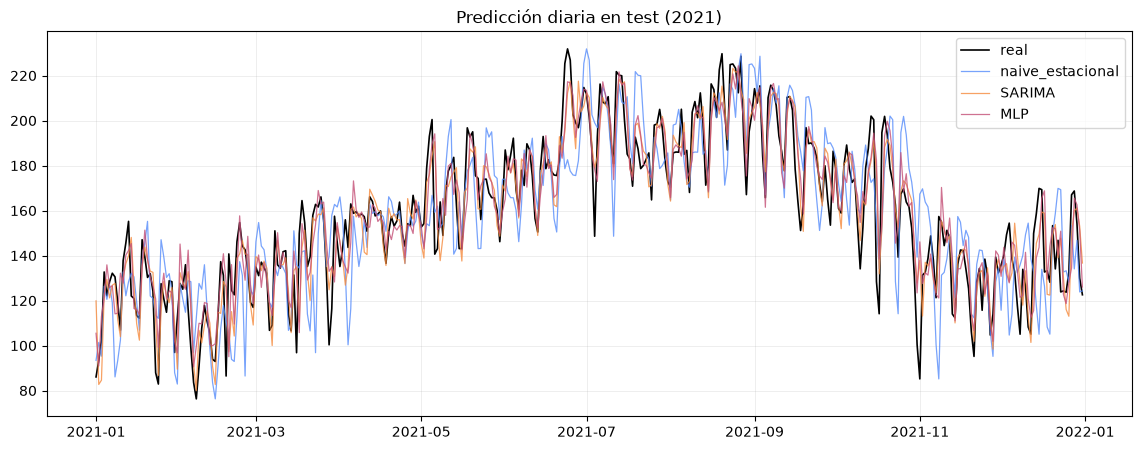

In [31]:
fechas = test.index[-len(yte):]                 # fechas del test
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(fechas, yte, label="real", color="black", lw=1.2)
for k, v in preds.items():
    ax.plot(fechas, v, label=k, lw=0.9, alpha=0.8)
ax.set_title("Predicción diaria en test (2021)")
ax.legend(); ax.grid(alpha=0.3); plt.show()

### 8.3 Métricas agregadas: semanal / mensual / anual

Las predicciones diarias se **suman** por período para obtener las estimaciones
de mayor granularidad temporal.

In [20]:
# Agrupa por período sumando real y predicho, y calcula métricas sobre los totales
def agregar(fechas, y_true, y_pred, regla):
    dd = pd.DataFrame({"real": y_true, "pred": y_pred}, index=pd.DatetimeIndex(fechas))
    a = dd.resample(regla).sum()          # W=semana, ME=fin de mes, YE=fin de año
    return metricas(a["real"].values, a["pred"].values)

filas = {}
for gran, regla in {"semanal":"W","mensual":"ME","anual":"YE"}.items():
    for nombre in ("SARIMA","MLP"):
        filas[f"{gran}:{nombre}"] = agregar(fechas, yte, preds[nombre], regla)
# El MAPE baja al agregar porque los errores diarios se compensan.
# Nota: el R2 anual sale NaN (el test tiene 1 solo año => 1 punto, indefinido).
pd.DataFrame(filas).T.round(3)

,MSE,RMSE,MAE,MAPE,R2
semanal:SARIMA,971.934,31.176,25.227,2.402,0.983
semanal:MLP,1035.732,32.183,25.363,2.530,0.982
mensual:SARIMA,3500.323,59.164,51.300,1.039,0.996
mensual:MLP,6439.900,80.249,70.215,1.521,0.992
anual:SARIMA,2153.540,46.406,46.406,0.080,NaN
anual:MLP,88764.426,297.934,297.934,0.515,NaN


## 9. Pronóstico a futuro: ¿cuánto será el día / semana / mes / año siguientes?

Hasta la sección 8 **evaluamos** los modelos sobre 2021 (un año que ya conocíamos),
para medir su error. Ahora hacemos un **pronóstico real**: proyectamos el consumo
hacia adelante, a fechas que **no están en los datos** (2022). Aquí ya no hay un
valor real contra el cual comparar — es el futuro.

Con ese pronóstico diario respondemos las cuatro preguntas del objetivo:

- **Día siguiente** → el primer día pronosticado.
- **Semana siguiente** → suma de los próximos 7 días.
- **Mes siguiente** → suma de los próximos 30 días.
- **Año siguiente** → suma de los próximos 365 días.

> **Mejora aplicada (SARIMA + Fourier anual):** el SARIMA de los talleres solo modela
> la estacionalidad **semanal** (período 7), por lo que al proyectar un año el
> pronóstico se **aplana** (no reproduce el ciclo verano/invierno). Para corregirlo le
> añadimos **términos de Fourier de período anual** (~365 días) como variables
> **exógenas** — esto se conoce como *regresión armónica dinámica* (SARIMAX): SARIMA
> sigue capturando la dinámica de corto plazo y los Fourier aportan la forma del ciclo
> anual. Así el pronóstico deja de verse plano.

> **Advertencia honesta (para la defensa):** mientras más lejos se proyecta, más se
> **acumula el error**. La **MLP** predice 1 día; para proyectar más lejos se usa de
> forma **recursiva** (realimenta sus propias predicciones), por lo que a largo plazo
> se amortigua hacia un valor casi constante y es menos fiable que SARIMA+Fourier.


In [21]:
# ============================================================================
# 9.1 Pronóstico a futuro con SARIMA + estacionalidad ANUAL (Fourier)
# ============================================================================
# PROBLEMA: SARIMA(2,1,2)(1,0,1,7) solo modela la estacionalidad SEMANAL (período 7);
# al proyectar un año el pronóstico se aplana (no reproduce el ciclo anual).
# SOLUCIÓN: agregamos variables EXÓGENAS de Fourier de período anual (~365.25 días).
# Son senos/cosenos deterministas que le dan al modelo la forma del ciclo anual;
# SARIMA sigue encargándose del corto plazo (semanal + autocorrelación). El modelo
# resultante es SARIMAX (X = regresores externos) = regresión armónica dinámica.
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Serie completa sin huecos (mismo criterio de relleno que en el modelado)
serie_completa = serie.ffill()
y_hist = serie_completa.values.astype("float32")

H = 365                 # horizonte: un año hacia adelante
PERIODO_ANUAL = 365.25  # período del ciclo anual (días)
K = 4                   # nº de armónicos de Fourier (más K = ciclo más detallado)

def terminos_fourier(t, period, K):
    """Columnas seno/coseno de Fourier para un índice de tiempo t.
    Cada armónico k aporta sin(2*pi*k*t/period) y cos(2*pi*k*t/period)."""
    t = np.asarray(t, dtype=float)
    cols = []
    for k in range(1, K + 1):
        cols.append(np.sin(2 * np.pi * k * t / period))
        cols.append(np.cos(2 * np.pi * k * t / period))
    return np.column_stack(cols)

# Índice de tiempo continuo: la historia va 0..N-1 y el futuro N..N+H-1 (misma fase)
N = len(y_hist)
exog_hist = terminos_fourier(np.arange(N),        PERIODO_ANUAL, K)  # para el ajuste
exog_fut  = terminos_fourier(np.arange(N, N + H), PERIODO_ANUAL, K)  # para el pronóstico

# Ajuste SARIMAX sobre TODA la historia: parte semanal + exógenas de Fourier (anual)
sarima_full = SARIMAX(y_hist, exog=exog_hist,
                      order=(2, 1, 2), seasonal_order=(1, 0, 1, 7),
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False)

# Pronóstico: hay que entregar las exógenas del futuro (los Fourier de 2022)
pred_futuro_sarima = sarima_full.forecast(steps=H, exog=exog_fut)

# Fechas futuras e índice del pronóstico (día a día desde el fin de los datos)
ultima_fecha = serie_completa.index.max()
fechas_futuras = pd.date_range(ultima_fecha + pd.Timedelta(days=1), periods=H, freq="D")
forecast_sarima = pd.Series(pred_futuro_sarima, index=fechas_futuras, name="pronostico")
print("Pronóstico SARIMA+Fourier de", fechas_futuras.min().date(),
      "a", fechas_futuras.max().date(), "(", H, "días,", K, "armónicos anuales )")
forecast_sarima.head()


Pronóstico SARIMA+Fourier de 2022-01-01 a 2022-12-31 ( 365 días, 4 armónicos anuales )


D:\MAGISTER\MSI608 TOPIC ESPECIAL CIENCIA DE DATO\proyecto1-2026\.venv311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2022-01-01    113.303571
2022-01-02    106.832952
2022-01-03    132.382588
2022-01-04    136.335774
2022-01-05    136.599809
Freq: D, Name: pronostico, dtype: float64

In [22]:
# ============================================================================
# 9.2 Pronóstico a futuro con la MLP (forma recursiva / iterativa)
# ============================================================================
# La MLP fue entrenada para predecir 1 día a partir de los WINDOW días previos.
# Para proyectar varios días la usamos de forma RECURSIVA: predecimos el día
# siguiente, ese valor lo agregamos a la ventana, y repetimos. Como se alimenta de
# sus propias predicciones, el error se acumula a medida que avanza el horizonte.

ventana = list(y_hist[-WINDOW:])   # últimos WINDOW días reales = punto de partida
pred_futuro_mlp = []

for _ in range(H):
    # tomamos los últimos WINDOW valores como entrada del modelo
    x = np.asarray(ventana[-WINDOW:], "float32").reshape(1, -1)
    # escalamos con mu/sg del train, predecimos y des-escalamos (igual que en 7.3)
    yhat = float(model.predict((x - mu) / sg, verbose=0).ravel()[0] * sg + mu)
    pred_futuro_mlp.append(yhat)
    ventana.append(yhat)           # realimentamos la predicción para el paso siguiente

forecast_mlp = pd.Series(pred_futuro_mlp, index=fechas_futuras, name="pronostico")
forecast_mlp.head()


2022-01-01    135.111725
2022-01-02    142.922531
2022-01-03    152.531342
2022-01-04    154.824066
2022-01-05    151.620056
Freq: D, Name: pronostico, dtype: float64

### 9.3 Resumen del pronóstico: día / semana / mes / año siguientes

A partir del pronóstico diario sumamos por período para obtener las cuatro
respuestas del objetivo. El **día siguiente** es un valor puntual; los demás son
**totales acumulados** de consumo en ese período futuro.


In [23]:
# ============================================================================
# 9.3 Cuánto será el día / semana / mes / año siguientes
# ============================================================================
def resumen_horizontes(forecast):
    """Convierte el pronóstico diario en los 4 horizontes pedidos."""
    return {
        "día siguiente":            float(forecast.iloc[0]),        # 1er día
        "semana siguiente (7 d)":   float(forecast.iloc[:7].sum()), # suma 7 días
        "mes siguiente (30 d)":     float(forecast.iloc[:30].sum()),# suma 30 días
        "año siguiente (365 d)":    float(forecast.iloc[:365].sum())# suma 365 días
    }

# Tabla comparando ambos modelos en las cuatro granularidades
resumen = pd.DataFrame({
    "SARIMA": resumen_horizontes(forecast_sarima),
    "MLP":    resumen_horizontes(forecast_mlp),
})
print("El 'día siguiente' corresponde a:", fechas_futuras[0].date())
print("(SARIMA es el pronóstico de referencia; MLP se muestra como contraste)\n")
resumen.round(2)


El 'día siguiente' corresponde a: 2022-01-01
(SARIMA es el pronóstico de referencia; MLP se muestra como contraste)



,SARIMA,MLP
día siguiente,113.30,135.11
semana siguiente (7 d),898.16,1015.55
mes siguiente (30 d),3826.55,4193.73
año siguiente (365 d),59095.08,50754.87


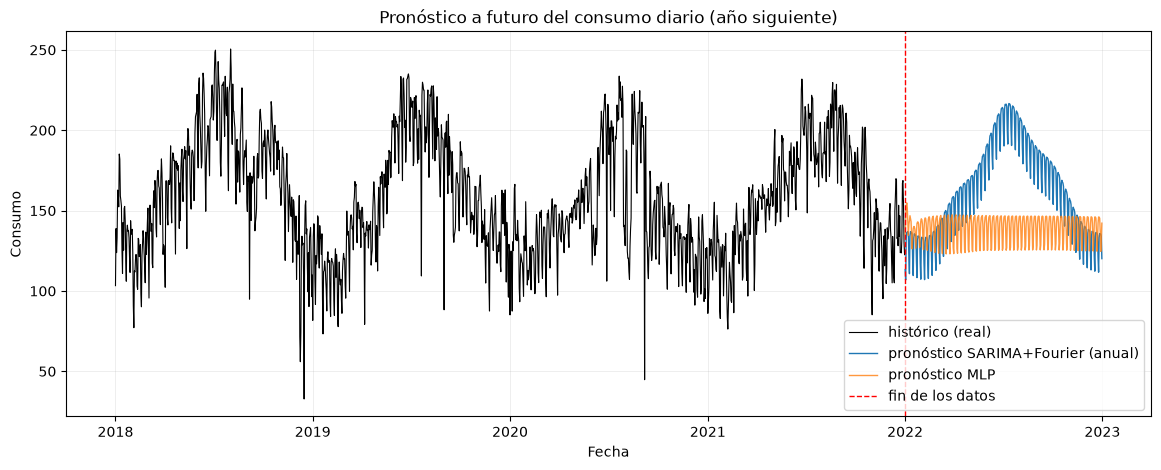

In [33]:
# Visualizamos la historia real y, a continuación, el pronóstico a futuro.
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(serie_completa.index, serie_completa.values,
        color="black", lw=0.8, label="histórico (real)")
ax.plot(forecast_sarima.index, forecast_sarima.values,
        color="tab:blue", lw=1.0, label="pronóstico SARIMA+Fourier (anual)")
ax.plot(forecast_mlp.index, forecast_mlp.values,
        color="tab:orange", lw=1.0, alpha=0.8, label="pronóstico MLP")
ax.axvline(ultima_fecha, color="red", ls="--", lw=1, label="fin de los datos")
ax.set_title("Pronóstico a futuro del consumo diario (año siguiente)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Consumo")
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()


### 9.4 Detalle del año siguiente (2022): consumo mes a mes

Desglosamos el pronóstico anual en sus 12 meses para ver **cómo quedarían los
valores del año siguiente**: el total de consumo de cada mes y su promedio diario.


In [35]:
# ============================================================================
# 9.4 Cómo quedarían los valores del AÑO SIGUIENTE (2022), mes a mes
# ============================================================================
# Agrupamos el pronóstico diario por mes calendario: suma = total mensual,
# mean = promedio diario dentro del mes. Se muestra para SARIMA y MLP.
detalle = pd.DataFrame({
    "SARIMA_total": forecast_sarima.resample("ME").sum(),   # total del mes (SARIMA)
    "MLP_total":    forecast_mlp.resample("ME").sum(),      # total del mes (MLP)
})
detalle["SARIMA_prom_diario"] = forecast_sarima.resample("ME").mean()  # promedio/día
detalle["MLP_prom_diario"]    = forecast_mlp.resample("ME").mean()

# Índice como 'AAAA-MM' (más legible que la fecha de fin de mes)
detalle.index = detalle.index.strftime("%Y-%m")
print("Pronóstico del año siguiente (2022): total y promedio diario por mes\n")
detalle.round(2)


Pronóstico del año siguiente (2022): total y promedio diario por mes



,SARIMA_total,MLP_total,SARIMA_prom_diario,MLP_prom_diario
2022-01,3957.24,4338.64,127.65,139.96
2022-02,3592.34,3895.89,128.30,139.14
2022-03,4446.04,4308.14,143.42,138.97
2022-04,4753.64,4150.93,158.45,138.36
2022-05,5323.95,4323.91,171.74,139.48
2022-06,5927.15,4153.81,197.57,138.46
2022-07,6424.38,4307.23,207.24,138.94
2022-08,5968.85,4326.68,192.54,139.57
2022-09,5356.72,4151.17,178.56,138.37
2022-10,5040.53,4331.87,162.60,139.74


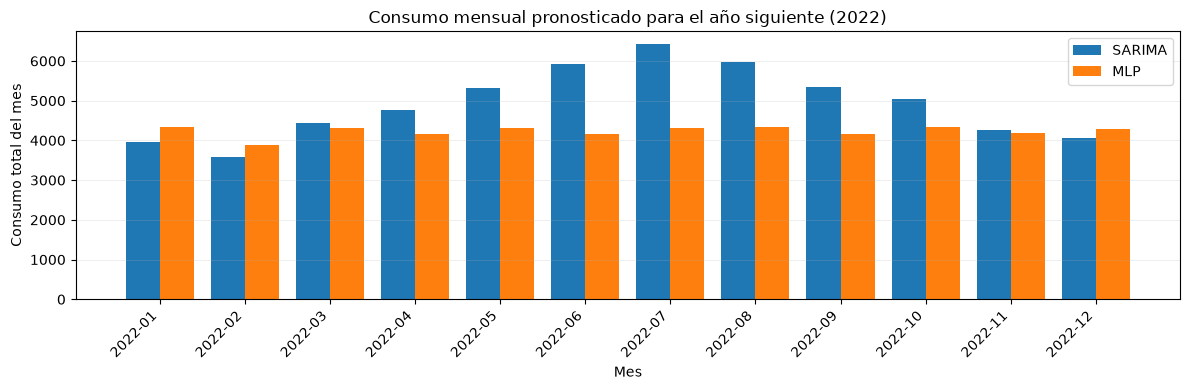

In [34]:
# Gráfico de barras: total mensual pronosticado para el año siguiente
fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(detalle)); ancho = 0.4
ax.bar(x - ancho/2, detalle["SARIMA_total"], ancho, label="SARIMA", color="tab:blue")
ax.bar(x + ancho/2, detalle["MLP_total"],    ancho, label="MLP",    color="tab:orange")
ax.set_xticks(x); ax.set_xticklabels(detalle.index, rotation=45, ha="right")
ax.set_title("Consumo mensual pronosticado para el año siguiente (2022)")
ax.set_xlabel("Mes"); ax.set_ylabel("Consumo total del mes")
ax.legend(); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


## 10. Conclusiones

- Se compararon tres técnicas: **naive estacional** (línea base), **SARIMA**
  (clásico) y **MLP** con arquitectura elegida por keras-tuner. El mejor modelo
  es el de menor RMSE/MAE en el test 2021.
- La **agregación** de las predicciones diarias entrega estimaciones coherentes
  a nivel semanal, mensual y anual (el MAPE tiende a bajar al agregar).
- **Limitaciones**: serie univariada (sin variables exógenas como clima,
  festivos o temperatura) y horizonte de un paso.
- **Trabajo futuro**: incorporar variables exógenas, probar modelos recurrentes
  (LSTM/GRU) y predicción multi-paso.

> Este notebook es autónomo: contiene el dataset embebido y todas las funciones,
> por lo que puede ejecutarse por sí solo sin archivos externos.